
# Family-fix chain audit: A) calibration→double-check logic chain, B) pseudo-truth center-offset audit

This notebook performs two audits using the saved `familyfix/results` outputs.

## Audit A: logic-chain / data-equivalence audit
Goal: re-check whether the calibration → final double-check chain is really using the intended objects, and whether the selected deployed object is mechanically reconstructed from the saved full-alpha bank without hidden mismatches.

Main checks:
1. file completeness and shared `x` / alpha grid consistency,
2. `deploy_final_rep*.csv` exactly reconstructs from `deploy_full_by_alpha_rep*.npz` + selected `alpha_star`,
3. selected estimated coverage exactly reconstructs from `pointwise_coverage_rep*.csv` + selected `alpha_star`,
4. on the selected-undercovered points, compare:
   - selected alpha,
   - best alpha by estimated coverage,
   - best alpha by actual deployed coverage.

## Audit B: pseudo-truth / center-offset audit
Goal: test the hypothesis:

> calibration CIs may cover pseudo-truth, but pseudo-truth may be off-center relative to the interval center, so the final deployed CI can still miss the real ground truth.

Important limitation:
- The saved results **do not contain the bootstrap calibration interval centers / widths** for every bootstrap replicate.
- Therefore, this notebook uses the **saved full-deploy alpha-bank** as the nearest available interval-center object.
- So Audit B is an **exact audit of pseudo-truth vs final deployed centers**, not an exact audit of pseudo-truth vs bootstrap-calibration centers.
- If this looks promising, the next run should save calibration-stage `(mu, std, lower, upper)` banks to audit this exact mechanism directly.

Project rule:
- Target is pointwise deployed coverage near 0.95.
- We focus on points that remain undercovered in the final selected deployed double check.
- Overcoverage is not the main issue here.


In [1]:

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

# Adjust if needed
RESULTS_DIR = Path(r"C:\Users\yangy\26 spring\with reference\familyfix\results")
OUTPUT_DIR = RESULTS_DIR / "chain_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR, OUTPUT_DIR


(WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results/chain_audit'))

In [2]:

DEPLOY_SELECTED_PATTERN = "deploy_final_rep*_J*.csv"
DEPLOY_BANK_PATTERN = "deploy_full_by_alpha_rep*_A*_J*.npz"
COVERAGE_PATTERN = "pointwise_coverage_rep*_A*_B*.csv"
ALPHA_STAR_PATTERN = "alpha_star_curve_rep*.csv"
PSEUDO_PATTERN = "pseudo_truth_rep*_A*_J*.npy"
META_PATTERN = "meta_rep*.json"

rep_regex = re.compile(r"rep(\d+)")

def parse_rep_id(path: Path) -> int:
    m = rep_regex.search(path.stem)
    if m is None:
        raise ValueError(f"Could not parse rep id from {path.name}")
    return int(m.group(1))

def load_optional_json(path: Path):
    if path is None or not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

deploy_selected_files = sorted(RESULTS_DIR.glob(DEPLOY_SELECTED_PATTERN), key=parse_rep_id)
deploy_bank_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(DEPLOY_BANK_PATTERN)}
coverage_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_PATTERN)}
alpha_star_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(ALPHA_STAR_PATTERN)}
pseudo_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(PSEUDO_PATTERN)}
meta_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(META_PATTERN)}

print(f"Found {len(deploy_selected_files)} selected deploy files")
print(f"Found {len(deploy_bank_files)} deploy alpha-bank files")
print(f"Found {len(coverage_files)} pointwise coverage files")
print(f"Found {len(alpha_star_files)} alpha-star files")
print(f"Found {len(pseudo_files)} pseudo-truth files")
print(f"Found {len(meta_files)} meta files")

if len(deploy_selected_files) == 0:
    raise FileNotFoundError(f"No files matching {DEPLOY_SELECTED_PATTERN} were found in {RESULTS_DIR}")

required = {
    "deploy_bank": deploy_bank_files,
    "coverage": coverage_files,
    "alpha_star": alpha_star_files,
    "pseudo_truth": pseudo_files,
    "meta": meta_files,
}
for name, mapping in required.items():
    missing = [parse_rep_id(p) for p in deploy_selected_files if parse_rep_id(p) not in mapping]
    if missing:
        raise FileNotFoundError(f"Missing {name} files for rep ids: {missing[:10]}")


Found 100 selected deploy files
Found 100 deploy alpha-bank files
Found 100 pointwise coverage files
Found 100 alpha-star files
Found 100 pseudo-truth files
Found 100 meta files


In [3]:

records = []
x_ref = None
true_f_ref = None
ci_level = None
z_ci = None
alpha_vals_ref = None

for deploy_path in deploy_selected_files:
    rep_id = parse_rep_id(deploy_path)

    deploy_df = pd.read_csv(deploy_path).sort_values("x").reset_index(drop=True)

    if x_ref is None:
        x_ref = deploy_df["x"].to_numpy(dtype=float)
        true_f_ref = deploy_df["true_f"].to_numpy(dtype=float)
    else:
        if not np.allclose(x_ref, deploy_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in selected deploy file for rep {rep_id}")
        if not np.allclose(true_f_ref, deploy_df["true_f"].to_numpy(dtype=float)):
            raise ValueError(f"true_f mismatch in selected deploy file for rep {rep_id}")

    meta = load_optional_json(meta_files.get(rep_id))
    if meta is not None and ci_level is None:
        ci_level = float(meta.get("ci_level", np.nan))
        z_ci = float(meta.get("z_ci", np.nan))

    alpha_df = pd.read_csv(alpha_star_files[rep_id]).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, alpha_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in alpha_star file for rep {rep_id}")

    cov_df = pd.read_csv(coverage_files[rep_id]).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, cov_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in pointwise coverage file for rep {rep_id}")

    alpha_cols = [c for c in cov_df.columns if c.startswith("alpha_")]
    alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)
    order = np.argsort(alpha_vals)
    alpha_vals = alpha_vals[order]
    alpha_cols = [alpha_cols[i] for i in order]
    cov_df = cov_df[["x"] + alpha_cols].copy()

    bank = np.load(deploy_bank_files[rep_id])
    bank_x = np.array(bank["x"], dtype=float)
    bank_alphas = np.array(bank["alphas"], dtype=float)
    mu_bank = np.array(bank["mu"], dtype=float)       # (A, J)
    std_bank = np.array(bank["std"], dtype=float)     # (A, J)
    lower_bank = np.array(bank["lower"], dtype=float) # (A, J)
    upper_bank = np.array(bank["upper"], dtype=float) # (A, J)

    pseudo_truth = np.load(pseudo_files[rep_id])      # (A, J)

    if not np.allclose(x_ref, bank_x):
        raise ValueError(f"x-grid mismatch in deploy alpha bank for rep {rep_id}")

    if alpha_vals_ref is None:
        alpha_vals_ref = bank_alphas.copy()
    else:
        if len(alpha_vals_ref) != len(bank_alphas) or not np.allclose(alpha_vals_ref, bank_alphas):
            raise ValueError(f"alpha grid mismatch in deploy alpha bank for rep {rep_id}")

    if len(alpha_vals) != len(bank_alphas) or not np.allclose(alpha_vals, bank_alphas):
        raise ValueError(f"coverage-vs-bank alpha grid mismatch for rep {rep_id}")

    if pseudo_truth.shape != mu_bank.shape:
        raise ValueError(
            f"pseudo_truth shape mismatch for rep {rep_id}: "
            f"{pseudo_truth.shape} vs {mu_bank.shape}"
        )

    records.append({
        "rep_id": rep_id,
        "deploy_df": deploy_df,
        "alpha_df": alpha_df,
        "coverage_df": cov_df,
        "meta": meta,
        "alphas": bank_alphas,
        "mu_bank": mu_bank,
        "std_bank": std_bank,
        "lower_bank": lower_bank,
        "upper_bank": upper_bank,
        "pseudo_truth": pseudo_truth,
    })

print(f"Loaded {len(records)} replications")
print(f"Nominal CI level from meta: {ci_level}")
print(f"z_ci from meta: {z_ci}")
print(f"Alpha grid: {alpha_vals_ref}")


Loaded 100 replications
Nominal CI level from meta: 0.95
z_ci from meta: 1.959963984540054
Alpha grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [4]:

rep_ids = np.array([r["rep_id"] for r in records], dtype=int)
R = len(records)
J = len(x_ref)
A = len(alpha_vals_ref)
nominal = float(ci_level) if ci_level is not None else 0.95

# selected deployed quantities
selected_hit_mat = np.vstack([r["deploy_df"]["hit"].to_numpy(dtype=float) for r in records])
selected_alpha_mat = np.vstack([r["deploy_df"]["alpha_star"].to_numpy(dtype=float) for r in records])

# all-alpha estimated coverage tensor: (R, J, A)
est_cov_all_tensor = np.stack(
    [r["coverage_df"].iloc[:, 1:].to_numpy(dtype=float) for r in records],
    axis=0,
)

# all-alpha actual deployed hit tensor from saved alpha banks: (R, J, A)
actual_hit_all_tensor = np.zeros((R, J, A), dtype=float)
mu_all_tensor = np.zeros((R, J, A), dtype=float)
std_all_tensor = np.zeros((R, J, A), dtype=float)
lower_all_tensor = np.zeros((R, J, A), dtype=float)
upper_all_tensor = np.zeros((R, J, A), dtype=float)
pseudo_all_tensor = np.zeros((R, J, A), dtype=float)

for r_idx, rec in enumerate(records):
    true_f = rec["deploy_df"]["true_f"].to_numpy(dtype=float)  # (J,)
    actual_hit_all_tensor[r_idx] = (
        (true_f[None, :] >= rec["lower_bank"]) &
        (true_f[None, :] <= rec["upper_bank"])
    ).T.astype(float)
    mu_all_tensor[r_idx] = rec["mu_bank"].T
    std_all_tensor[r_idx] = rec["std_bank"].T
    lower_all_tensor[r_idx] = rec["lower_bank"].T
    upper_all_tensor[r_idx] = rec["upper_bank"].T
    pseudo_all_tensor[r_idx] = rec["pseudo_truth"].T

# pointwise selected summaries
pointwise_selected_actual = selected_hit_mat.mean(axis=0)

selected_est_cov_mat = np.zeros((R, J), dtype=float)
selected_mu_mat = np.zeros((R, J), dtype=float)
selected_std_mat = np.zeros((R, J), dtype=float)
selected_lower_mat = np.zeros((R, J), dtype=float)
selected_upper_mat = np.zeros((R, J), dtype=float)
selected_pseudo_mat = np.zeros((R, J), dtype=float)

recon_rows = []
for r_idx, rec in enumerate(records):
    deploy_df = rec["deploy_df"]
    alpha_vec = deploy_df["alpha_star"].to_numpy(dtype=float)
    alpha_idx = np.array([int(np.argmin(np.abs(alpha_vals_ref - a))) for a in alpha_vec], dtype=int)

    cov_mat = rec["coverage_df"].iloc[:, 1:].to_numpy(dtype=float)
    selected_est_cov_mat[r_idx] = cov_mat[np.arange(J), alpha_idx]

    mu_bank = rec["mu_bank"]
    std_bank = rec["std_bank"]
    lower_bank = rec["lower_bank"]
    upper_bank = rec["upper_bank"]
    pseudo_bank = rec["pseudo_truth"]

    selected_mu = mu_bank[alpha_idx, np.arange(J)]
    selected_std = std_bank[alpha_idx, np.arange(J)]
    selected_lower = lower_bank[alpha_idx, np.arange(J)]
    selected_upper = upper_bank[alpha_idx, np.arange(J)]
    selected_pseudo = pseudo_bank[alpha_idx, np.arange(J)]

    selected_mu_mat[r_idx] = selected_mu
    selected_std_mat[r_idx] = selected_std
    selected_lower_mat[r_idx] = selected_lower
    selected_upper_mat[r_idx] = selected_upper
    selected_pseudo_mat[r_idx] = selected_pseudo

    alpha_curve = rec["alpha_df"]["alpha_star"].to_numpy(dtype=float)
    recon_rows.append({
        "rep_id": int(rec["rep_id"]),
        "max_abs_alpha_diff_deploy_vs_curve": float(np.max(np.abs(alpha_vec - alpha_curve))),
        "max_abs_mu_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_mu - deploy_df["mu"].to_numpy(dtype=float)))),
        "max_abs_std_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_std - deploy_df["std"].to_numpy(dtype=float)))),
        "max_abs_lower_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_lower - deploy_df["lower"].to_numpy(dtype=float)))),
        "max_abs_upper_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_upper - deploy_df["upper"].to_numpy(dtype=float)))),
        "hit_match_all_points": bool(np.array_equal(
            ((true_f_ref >= selected_lower) & (true_f_ref <= selected_upper)).astype(np.int8),
            deploy_df["hit"].to_numpy(dtype=np.int8),
        )),
    })

recon_df = pd.DataFrame(recon_rows)
recon_df.to_csv(OUTPUT_DIR / "00_reconstruction_consistency_per_rep.csv", index=False)

pointwise_selected_estimated = selected_est_cov_mat.mean(axis=0)
actual_cov_all_mean = actual_hit_all_tensor.mean(axis=0)
est_cov_all_mean = est_cov_all_tensor.mean(axis=0)
actual_minus_est_mean = actual_cov_all_mean - est_cov_all_mean

under_mask = pointwise_selected_actual < nominal
under_idx = np.flatnonzero(under_mask)
U = len(under_idx)

summary = {
    "R": int(R),
    "J": int(J),
    "A": int(A),
    "rep_id_min": int(rep_ids.min()),
    "rep_id_max": int(rep_ids.max()),
    "nominal": float(nominal),
    "undercovered_selected_points": int(U),
    "recon_all_alpha_curve_match": bool(np.allclose(recon_df["max_abs_alpha_diff_deploy_vs_curve"].to_numpy(dtype=float), 0.0)),
    "recon_all_mu_match": bool(np.allclose(recon_df["max_abs_mu_diff_reconstructed_vs_saved"].to_numpy(dtype=float), 0.0)),
    "recon_all_std_match": bool(np.allclose(recon_df["max_abs_std_diff_reconstructed_vs_saved"].to_numpy(dtype=float), 0.0)),
    "recon_all_lower_match": bool(np.allclose(recon_df["max_abs_lower_diff_reconstructed_vs_saved"].to_numpy(dtype=float), 0.0)),
    "recon_all_upper_match": bool(np.allclose(recon_df["max_abs_upper_diff_reconstructed_vs_saved"].to_numpy(dtype=float), 0.0)),
    "recon_all_hit_match": bool(recon_df["hit_match_all_points"].all()),
}
pd.DataFrame([summary]).to_csv(OUTPUT_DIR / "00_chain_audit_summary.csv", index=False)
summary


{'R': 100,
 'J': 50,
 'A': 10,
 'rep_id_min': 0,
 'rep_id_max': 99,
 'nominal': 0.95,
 'undercovered_selected_points': 9,
 'recon_all_alpha_curve_match': True,
 'recon_all_mu_match': True,
 'recon_all_std_match': True,
 'recon_all_lower_match': True,
 'recon_all_upper_match': True,
 'recon_all_hit_match': True}


## Audit A1: object-chain table

This is a human-readable audit table describing what object each saved artifact represents, what data split it depends on, and whether it is truth-free.


In [5]:

object_chain_df = pd.DataFrame([
    {
        "stage": "calibration",
        "object": "pseudo_truth(alpha, x)",
        "saved_artifact": "pseudo_truth_repXXX_AA_JJ.npy",
        "shape_example": f"({A}, {J})",
        "depends_on": "split-1 Stage-1 + Stage-2 family on D1",
        "truth_free": True,
        "role": "surrogate target used during calibration",
    },
    {
        "stage": "calibration",
        "object": "estimated pointwise coverage(alpha, x)",
        "saved_artifact": "pointwise_coverage_repXXX_A*_B*.csv",
        "shape_example": f"({J}, {A}) after removing x column",
        "depends_on": "split-2 bootstrap with same-family interval generator",
        "truth_free": True,
        "role": "estimated coverage surface used to choose alpha",
    },
    {
        "stage": "selection",
        "object": "alpha_star(x)",
        "saved_artifact": "alpha_star_curve_repXXX.csv / alpha_star_repXXX_JJ.npy",
        "shape_example": f"({J},)",
        "depends_on": "estimated pointwise coverage only",
        "truth_free": True,
        "role": "dictionary-selected alpha per test point",
    },
    {
        "stage": "deployment",
        "object": "full-data all-alpha interval bank",
        "saved_artifact": "deploy_full_by_alpha_repXXX_AA_JJ.npz",
        "shape_example": f"mu/std/lower/upper: ({A}, {J})",
        "depends_on": "full-data Stage-1 base + full-data Stage-2 for each alpha",
        "truth_free": True,
        "role": "actual deployed family used for final double check",
    },
    {
        "stage": "deployment",
        "object": "selected deployed interval",
        "saved_artifact": "deploy_final_repXXX_JJ.csv",
        "shape_example": f"({J},) per column",
        "depends_on": "pointwise lookup from all-alpha deploy bank using alpha_star(x)",
        "truth_free": True,
        "role": "actual final deployed object under the selected alpha rule",
    },
    {
        "stage": "simulation audit only",
        "object": "actual deployed coverage(alpha, x)",
        "saved_artifact": "derived from deploy_full_by_alpha + true_f",
        "shape_example": f"({J}, {A}) after replication averaging",
        "depends_on": "known simulation truth only",
        "truth_free": False,
        "role": "oracle diagnostic only; not available in real deployment",
    },
])
object_chain_df.to_csv(OUTPUT_DIR / "01_object_chain_table.csv", index=False)
object_chain_df


,stage,object,saved_artifact,shape_example,depends_on,truth_free,role
0,calibration,"pseudo_truth(alpha, x)",pseudo_truth_repXXX_AA_JJ.npy,"(10, 50)",split-1 Stage-1 + Stage-2 family on D1,True,surrogate target used during calibration
1,calibration,"estimated pointwise coverage(alpha, x)",pointwise_coverage_repXXX_A*_B*.csv,"(50, 10) after removing x column",split-2 bootstrap with same-family interval ge...,True,estimated coverage surface used to choose alpha
2,selection,alpha_star(x),alpha_star_curve_repXXX.csv / alpha_star_repXX...,"(50,)",estimated pointwise coverage only,True,dictionary-selected alpha per test point
3,deployment,full-data all-alpha interval bank,deploy_full_by_alpha_repXXX_AA_JJ.npz,"mu/std/lower/upper: (10, 50)",full-data Stage-1 base + full-data Stage-2 for...,True,actual deployed family used for final double c...
4,deployment,selected deployed interval,deploy_final_repXXX_JJ.csv,"(50,) per column",pointwise lookup from all-alpha deploy bank us...,True,actual final deployed object under the selecte...
5,simulation audit only,"actual deployed coverage(alpha, x)",derived from deploy_full_by_alpha + true_f,"(50, 10) after replication averaging",known simulation truth only,False,oracle diagnostic only; not available in real ...



## Audit A2: mechanical reconstruction audit

If this section shows exact reconstruction, then the problem is probably **not** a low-level bookkeeping error between:
- selected `alpha_star`,
- saved full-alpha deployment bank,
- saved selected deployed CSV.

That does **not** prove the statistical targets are equivalent, but it clears the simplest file/lookup mismatch suspicion.


In [6]:

recon_df.describe(include="all")


,rep_id,max_abs_alpha_diff_deploy_vs_curve,max_abs_mu_diff_reconstructed_vs_saved,max_abs_std_diff_reconstructed_vs_saved,max_abs_lower_diff_reconstructed_vs_saved,max_abs_upper_diff_reconstructed_vs_saved,hit_match_all_points
count,100.000000,100.0,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100
unique,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,100
mean,49.500000,0.0,2.117750e-16,9.738738e-17,2.127465e-16,2.103873e-16,NaN
std,29.011492,0.0,3.292485e-17,1.726292e-18,3.180902e-17,3.532488e-17,NaN
min,0.000000,0.0,8.326673e-17,9.194034e-17,8.326673e-17,8.326673e-17,NaN
25%,24.750000,0.0,2.220446e-16,9.714451e-17,2.220446e-16,2.220446e-16,NaN
50%,49.500000,0.0,2.220446e-16,9.714451e-17,2.220446e-16,2.220446e-16,NaN
75%,74.250000,0.0,2.220446e-16,9.887924e-17,2.220446e-16,2.220446e-16,NaN


In [7]:

pointwise_selected_table = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_actual_deploy_coverage": pointwise_selected_actual,
    "selected_estimated_coverage": pointwise_selected_estimated,
    "selected_actual_minus_estimated": pointwise_selected_actual - pointwise_selected_estimated,
    "alpha_star_mean": selected_alpha_mat.mean(axis=0),
    "alpha_star_sd": selected_alpha_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J),
    "nominal": nominal,
    "selected_gap_to_nominal": nominal - pointwise_selected_actual,
})
pointwise_selected_table.to_csv(OUTPUT_DIR / "02_pointwise_selected_chain_summary.csv", index=False)

undercovered_selected_summary = pointwise_selected_table.loc[under_mask].copy()
undercovered_selected_summary = undercovered_selected_summary.sort_values(
    ["selected_gap_to_nominal", "x"], ascending=[False, True]
).reset_index(drop=True)
undercovered_selected_summary.to_csv(OUTPUT_DIR / "03_undercovered_selected_chain_summary.csv", index=False)
undercovered_selected_summary


,x,true_f,selected_actual_deploy_coverage,selected_estimated_coverage,selected_actual_minus_estimated,alpha_star_mean,alpha_star_sd,nominal,selected_gap_to_nominal
0,-1.887755,1.055191,0.84,0.9672,-0.1272,0.755,0.249596,0.95,0.11
1,-1.581633,0.506969,0.84,0.9828,-0.1428,0.961,0.116250,0.95,0.11
2,-2.193878,-0.460571,0.87,0.9644,-0.0944,0.698,0.291281,0.95,0.08
3,-2.295918,-0.547295,0.88,0.9707,-0.0907,0.832,0.253811,0.95,0.07
4,-1.989796,0.539654,0.89,0.9874,-0.0974,0.987,0.067652,0.95,0.06
5,-1.479592,-0.262983,0.91,0.9650,-0.0550,0.782,0.243036,0.95,0.04
6,-1.173469,-1.351151,0.92,0.9896,-0.0696,0.976,0.099615,0.95,0.03
7,2.091837,1.045520,0.94,0.9672,-0.0272,0.746,0.275395,0.95,0.01
8,2.500000,0.173318,0.94,0.9792,-0.0392,0.897,0.217634,0.95,0.01



## Audit A3: on the undercovered selected points, compare:
- selected alpha behavior,
- best alpha by estimated mean,
- best alpha by actual deployed mean.

This directly tests whether the chain problem is:
- no deployed alpha near nominal, or
- the deployed family **does** contain a good alpha, but the calibration-side choice does not land on it.


In [8]:

compare_rows = []
if U > 0:
    for j in under_idx:
        est_vec = est_cov_all_mean[j, :]
        act_vec = actual_cov_all_mean[j, :]
        best_est_idx = int(np.argmin(np.abs(est_vec - nominal)))
        best_act_idx = int(np.argmin(np.abs(act_vec - nominal)))
        compare_rows.append({
            "x": float(x_ref[j]),
            "true_f": float(true_f_ref[j]),
            "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
            "selected_estimated_coverage": float(pointwise_selected_estimated[j]),
            "selected_actual_minus_estimated": float(pointwise_selected_actual[j] - pointwise_selected_estimated[j]),
            "selected_alpha_mean": float(selected_alpha_mat[:, j].mean()),
            "selected_alpha_sd": float(selected_alpha_mat[:, j].std(ddof=1)) if R > 1 else 0.0,
            "best_alpha_by_estimated_mean": float(alpha_vals_ref[best_est_idx]),
            "best_estimated_coverage": float(est_vec[best_est_idx]),
            "best_estimated_abs_error_to_nominal": float(abs(est_vec[best_est_idx] - nominal)),
            "best_alpha_by_actual_deploy_mean": float(alpha_vals_ref[best_act_idx]),
            "best_actual_deploy_coverage": float(act_vec[best_act_idx]),
            "best_actual_abs_error_to_nominal": float(abs(act_vec[best_act_idx] - nominal)),
            "best_alpha_match": bool(np.isclose(alpha_vals_ref[best_est_idx], alpha_vals_ref[best_act_idx])),
        })
compare_df = pd.DataFrame(compare_rows)
compare_df.to_csv(OUTPUT_DIR / "04_undercovered_best_alpha_chain_compare.csv", index=False)
compare_df


,x,true_f,selected_actual_deploy_coverage,selected_estimated_coverage,selected_actual_minus_estimated,selected_alpha_mean,selected_alpha_sd,best_alpha_by_estimated_mean,best_estimated_coverage,best_estimated_abs_error_to_nominal,best_alpha_by_actual_deploy_mean,best_actual_deploy_coverage,best_actual_abs_error_to_nominal,best_alpha_match
0,-2.295918,-0.547295,0.88,0.9707,-0.0907,0.832,0.253811,0.7,0.9505,0.0005,0.5,0.95,0.00,False
1,-2.193878,-0.460571,0.87,0.9644,-0.0944,0.698,0.291281,0.5,0.9475,0.0025,0.3,0.93,0.02,False
2,-1.989796,0.539654,0.89,0.9874,-0.0974,0.987,0.067652,1.0,0.9795,0.0295,0.6,0.95,0.00,False
3,-1.887755,1.055191,0.84,0.9672,-0.1272,0.755,0.249596,0.6,0.9478,0.0022,0.2,0.96,0.01,False
4,-1.581633,0.506969,0.84,0.9828,-0.1428,0.961,0.116250,1.0,0.9666,0.0166,0.4,0.96,0.01,False
5,-1.479592,-0.262983,0.91,0.9650,-0.0550,0.782,0.243036,0.6,0.9510,0.0010,0.4,0.95,0.00,False
6,-1.173469,-1.351151,0.92,0.9896,-0.0696,0.976,0.099615,1.0,0.9758,0.0258,0.8,0.95,0.00,False
7,2.091837,1.045520,0.94,0.9672,-0.0272,0.746,0.275395,0.5,0.9538,0.0038,0.6,0.95,0.00,False
8,2.500000,0.173318,0.94,0.9792,-0.0392,0.897,0.217634,0.8,0.9503,0.0003,1.0,0.93,0.02,False


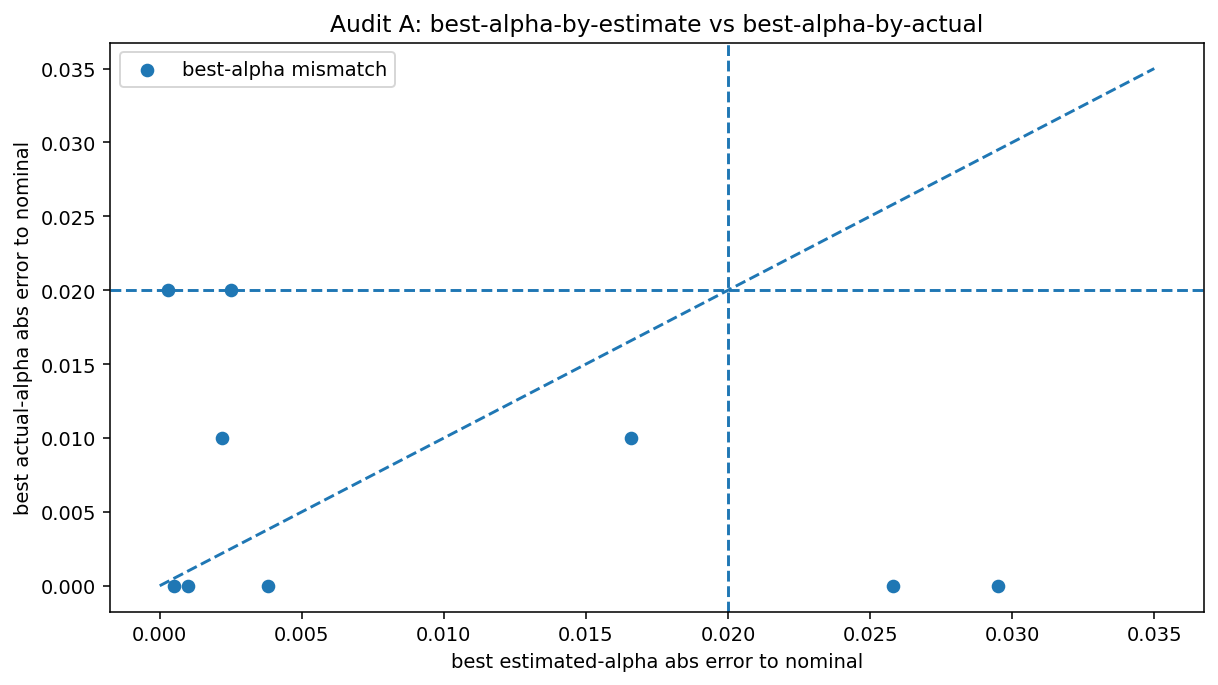

In [9]:

if U > 0:
    plt.figure(figsize=(8.8, 5.0))
    xvals = compare_df["best_estimated_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = compare_df["best_actual_abs_error_to_nominal"].to_numpy(dtype=float)
    match = compare_df["best_alpha_match"].to_numpy(dtype=bool)

    plt.scatter(xvals[~match], yvals[~match], label="best-alpha mismatch")
    if np.any(match):
        plt.scatter(xvals[match], yvals[match], label="best-alpha match")

    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0), 0.03) + 0.005
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.axhline(0.02, linestyle="--")
    plt.axvline(0.02, linestyle="--")
    plt.xlabel("best estimated-alpha abs error to nominal")
    plt.ylabel("best actual-alpha abs error to nominal")
    plt.title("Audit A: best-alpha-by-estimate vs best-alpha-by-actual")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_best_alpha_chain_compare_scatter.png", bbox_inches="tight")
    plt.show()



# Audit B: pseudo-truth / center-offset audit

Reminder: this uses the **saved full-deploy interval centers** as the nearest available saved center object.

For each replication and point, under the **selected alpha** we compute:

\[
z_{\text{pseudo}} = \frac{\tilde f - \mu}{\sigma},
\qquad
z_{\text{true}} = \frac{f_0 - \mu}{\sigma}
\]

where:
- \(\tilde f\) is the saved pseudo-truth for the selected alpha,
- \((\mu,\sigma)\) come from the saved full-deploy alpha bank,
- \(f_0\) is the known simulation truth (audit only).

Interpretation:
- if \(|z_{\text{pseudo}}|\) is often large, pseudo-truth is off-center relative to the deployed interval center,
- if pseudo-truth is often covered but true \(f_0\) is not, then pseudo-truth may be systematically easier to cover than the true target.


In [10]:

eps = 1e-12
selected_pseudo_z = (selected_pseudo_mat - selected_mu_mat) / np.maximum(selected_std_mat, eps)
selected_true_z = (true_f_ref[None, :] - selected_mu_mat) / np.maximum(selected_std_mat, eps)

selected_pseudo_hit_mat = (
    (selected_pseudo_mat >= selected_lower_mat) &
    (selected_pseudo_mat <= selected_upper_mat)
).astype(float)
selected_true_hit_mat = selected_hit_mat.astype(float)

selected_same_side_mat = (np.sign(selected_pseudo_z) == np.sign(selected_true_z)).astype(float)
selected_pseudo_farther_abs_mat = (np.abs(selected_pseudo_z) > np.abs(selected_true_z)).astype(float)
selected_pseudo_near_edge_mat = (
    (np.abs(selected_pseudo_z) >= 0.8 * z_ci) &
    (np.abs(selected_pseudo_z) <= z_ci)
).astype(float)
selected_true_near_edge_mat = (
    (np.abs(selected_true_z) >= 0.8 * z_ci) &
    (np.abs(selected_true_z) <= z_ci)
).astype(float)

center_offset_summary = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_actual_deploy_coverage": selected_true_hit_mat.mean(axis=0),
    "selected_pseudo_hit_share": selected_pseudo_hit_mat.mean(axis=0),
    "pseudo_minus_true_hit_share": selected_pseudo_hit_mat.mean(axis=0) - selected_true_hit_mat.mean(axis=0),
    "mean_selected_pseudo_z": selected_pseudo_z.mean(axis=0),
    "mean_selected_true_z": selected_true_z.mean(axis=0),
    "mean_abs_selected_pseudo_z": np.abs(selected_pseudo_z).mean(axis=0),
    "mean_abs_selected_true_z": np.abs(selected_true_z).mean(axis=0),
    "share_same_side": selected_same_side_mat.mean(axis=0),
    "share_pseudo_farther_from_center_than_true": selected_pseudo_farther_abs_mat.mean(axis=0),
    "share_pseudo_near_edge": selected_pseudo_near_edge_mat.mean(axis=0),
    "share_true_near_edge": selected_true_near_edge_mat.mean(axis=0),
})
center_offset_summary.to_csv(OUTPUT_DIR / "05_selected_center_offset_summary.csv", index=False)

undercovered_center_offset_summary = center_offset_summary.loc[under_mask].copy()
undercovered_center_offset_summary = undercovered_center_offset_summary.sort_values(
    ["selected_actual_deploy_coverage", "x"], ascending=[True, True]
).reset_index(drop=True)
undercovered_center_offset_summary.to_csv(
    OUTPUT_DIR / "06_undercovered_selected_center_offset_summary.csv",
    index=False,
)
undercovered_center_offset_summary


,x,true_f,selected_actual_deploy_coverage,selected_pseudo_hit_share,pseudo_minus_true_hit_share,mean_selected_pseudo_z,mean_selected_true_z,mean_abs_selected_pseudo_z,mean_abs_selected_true_z,share_same_side,share_pseudo_farther_from_center_than_true,share_pseudo_near_edge,share_true_near_edge
0,-1.887755,1.055191,0.84,0.92,0.08,0.364495,1.312222,0.785788,1.312222,0.74,0.08,0.11,0.06
1,-1.581633,0.506969,0.84,0.94,0.10,-0.448597,-1.330908,0.706428,1.330908,0.81,0.06,0.09,0.07
2,-2.193878,-0.460571,0.87,0.91,0.04,-0.279875,-1.231497,0.669963,1.231497,0.78,0.09,0.03,0.05
3,-2.295918,-0.547295,0.88,0.95,0.07,-0.105324,-0.700199,0.659930,0.700199,0.56,0.44,0.09,0.01
4,-1.989796,0.539654,0.89,0.97,0.08,0.205706,1.069915,0.600245,1.069915,0.63,0.11,0.05,0.06
5,-1.479592,-0.262983,0.91,0.93,0.02,-0.380498,-0.744786,0.709720,0.744786,0.73,0.46,0.05,0.03
6,-1.173469,-1.351151,0.92,0.96,0.04,0.424378,0.876383,0.705060,0.876383,0.79,0.23,0.07,0.07
7,2.091837,1.045520,0.94,0.94,0.00,0.158749,0.931300,0.740357,0.931849,0.64,0.28,0.05,0.03
8,2.500000,0.173318,0.94,1.00,0.06,0.267144,0.999065,0.535254,0.999065,0.76,0.06,0.03,0.05


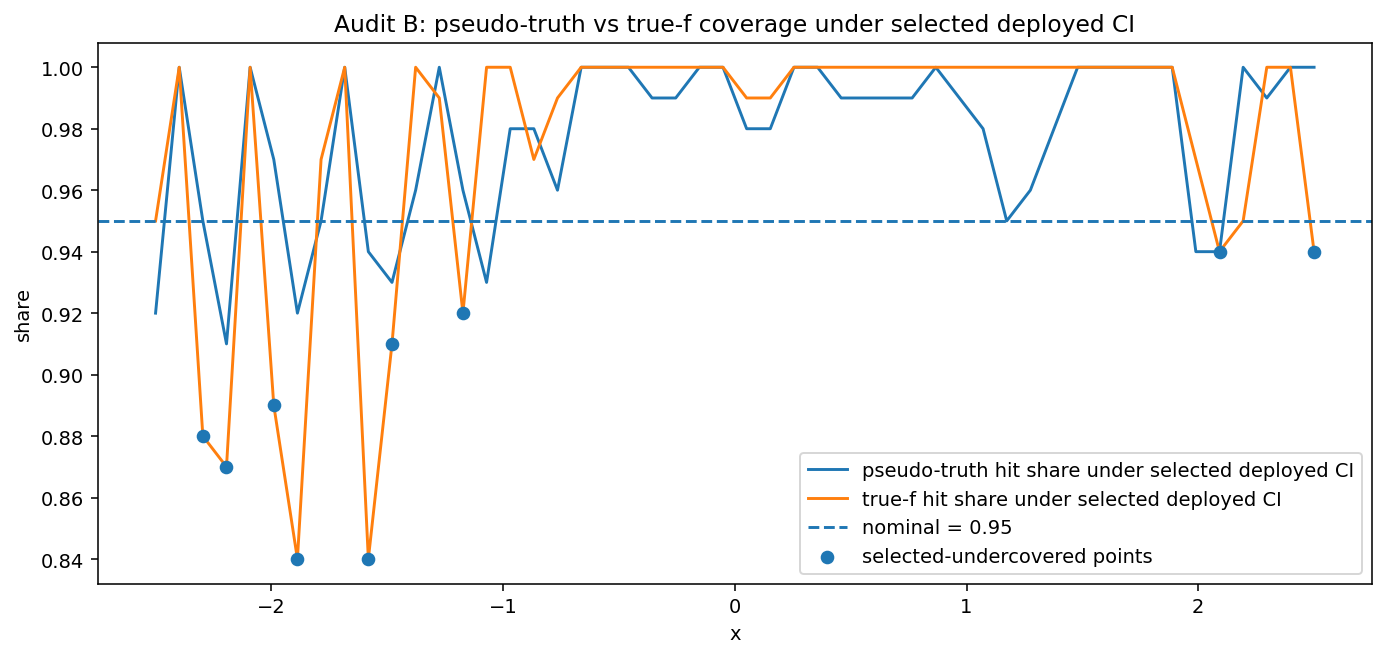

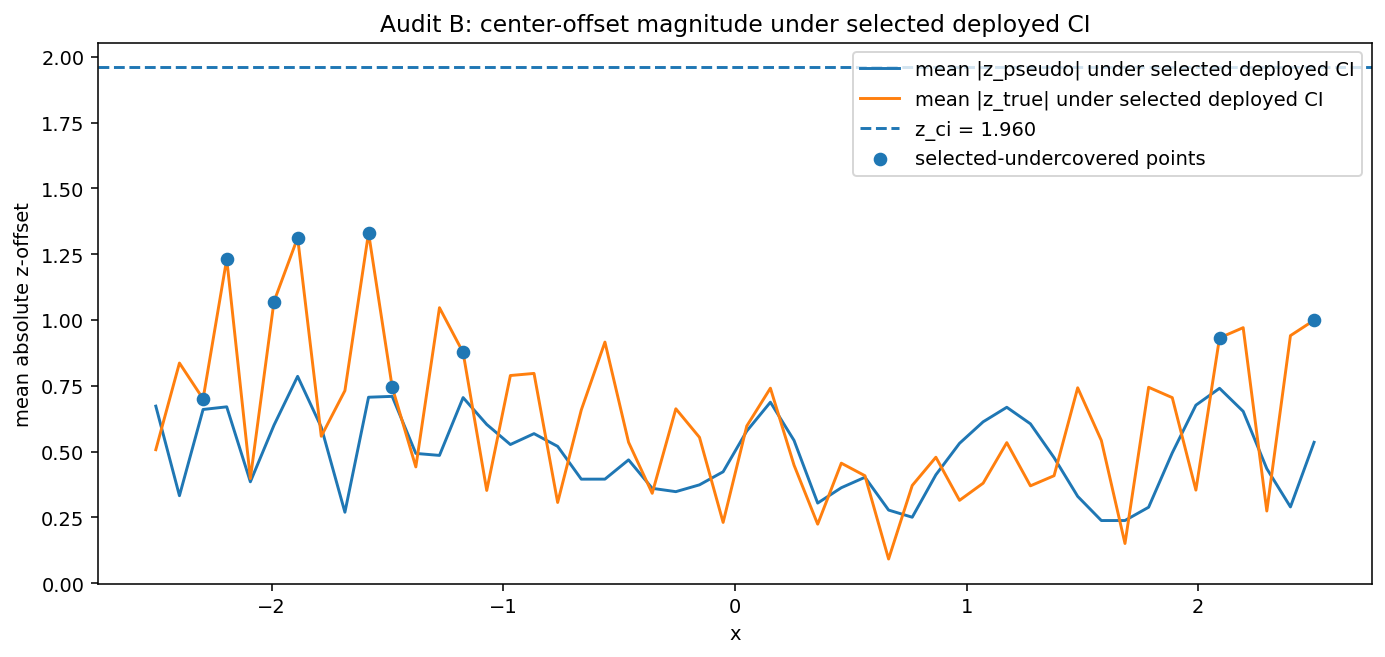

In [11]:

if U > 0:
    plt.figure(figsize=(10, 4.8))
    plt.plot(x_ref, center_offset_summary["selected_pseudo_hit_share"], label="pseudo-truth hit share under selected deployed CI")
    plt.plot(x_ref, center_offset_summary["selected_actual_deploy_coverage"], label="true-f hit share under selected deployed CI")
    plt.axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
    plt.scatter(
        x_ref[under_idx],
        center_offset_summary.loc[under_mask, "selected_actual_deploy_coverage"],
        label="selected-undercovered points",
        zorder=3,
    )
    plt.xlabel("x")
    plt.ylabel("share")
    plt.title("Audit B: pseudo-truth vs true-f coverage under selected deployed CI")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_selected_pseudo_vs_true_hit_share.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4.8))
    plt.plot(x_ref, center_offset_summary["mean_abs_selected_pseudo_z"], label="mean |z_pseudo| under selected deployed CI")
    plt.plot(x_ref, center_offset_summary["mean_abs_selected_true_z"], label="mean |z_true| under selected deployed CI")
    plt.axhline(z_ci, linestyle="--", label=f"z_ci = {z_ci:.3f}")
    plt.scatter(
        x_ref[under_idx],
        center_offset_summary.loc[under_mask, "mean_abs_selected_true_z"],
        label="selected-undercovered points",
        zorder=3,
    )
    plt.xlabel("x")
    plt.ylabel("mean absolute z-offset")
    plt.title("Audit B: center-offset magnitude under selected deployed CI")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "07_selected_center_offset_magnitude.png", bbox_inches="tight")
    plt.show()



## Audit B2: all-alpha pseudo-vs-true center-offset surfaces on the selected-undercovered points

These diagnostics answer:
- on the points that remain undercovered under the selected alpha, is pseudo-truth systematically easier to cover than true \(f_0\) across the whole alpha dictionary?
- is pseudo-truth more centered than true \(f_0\) relative to the deployed intervals?


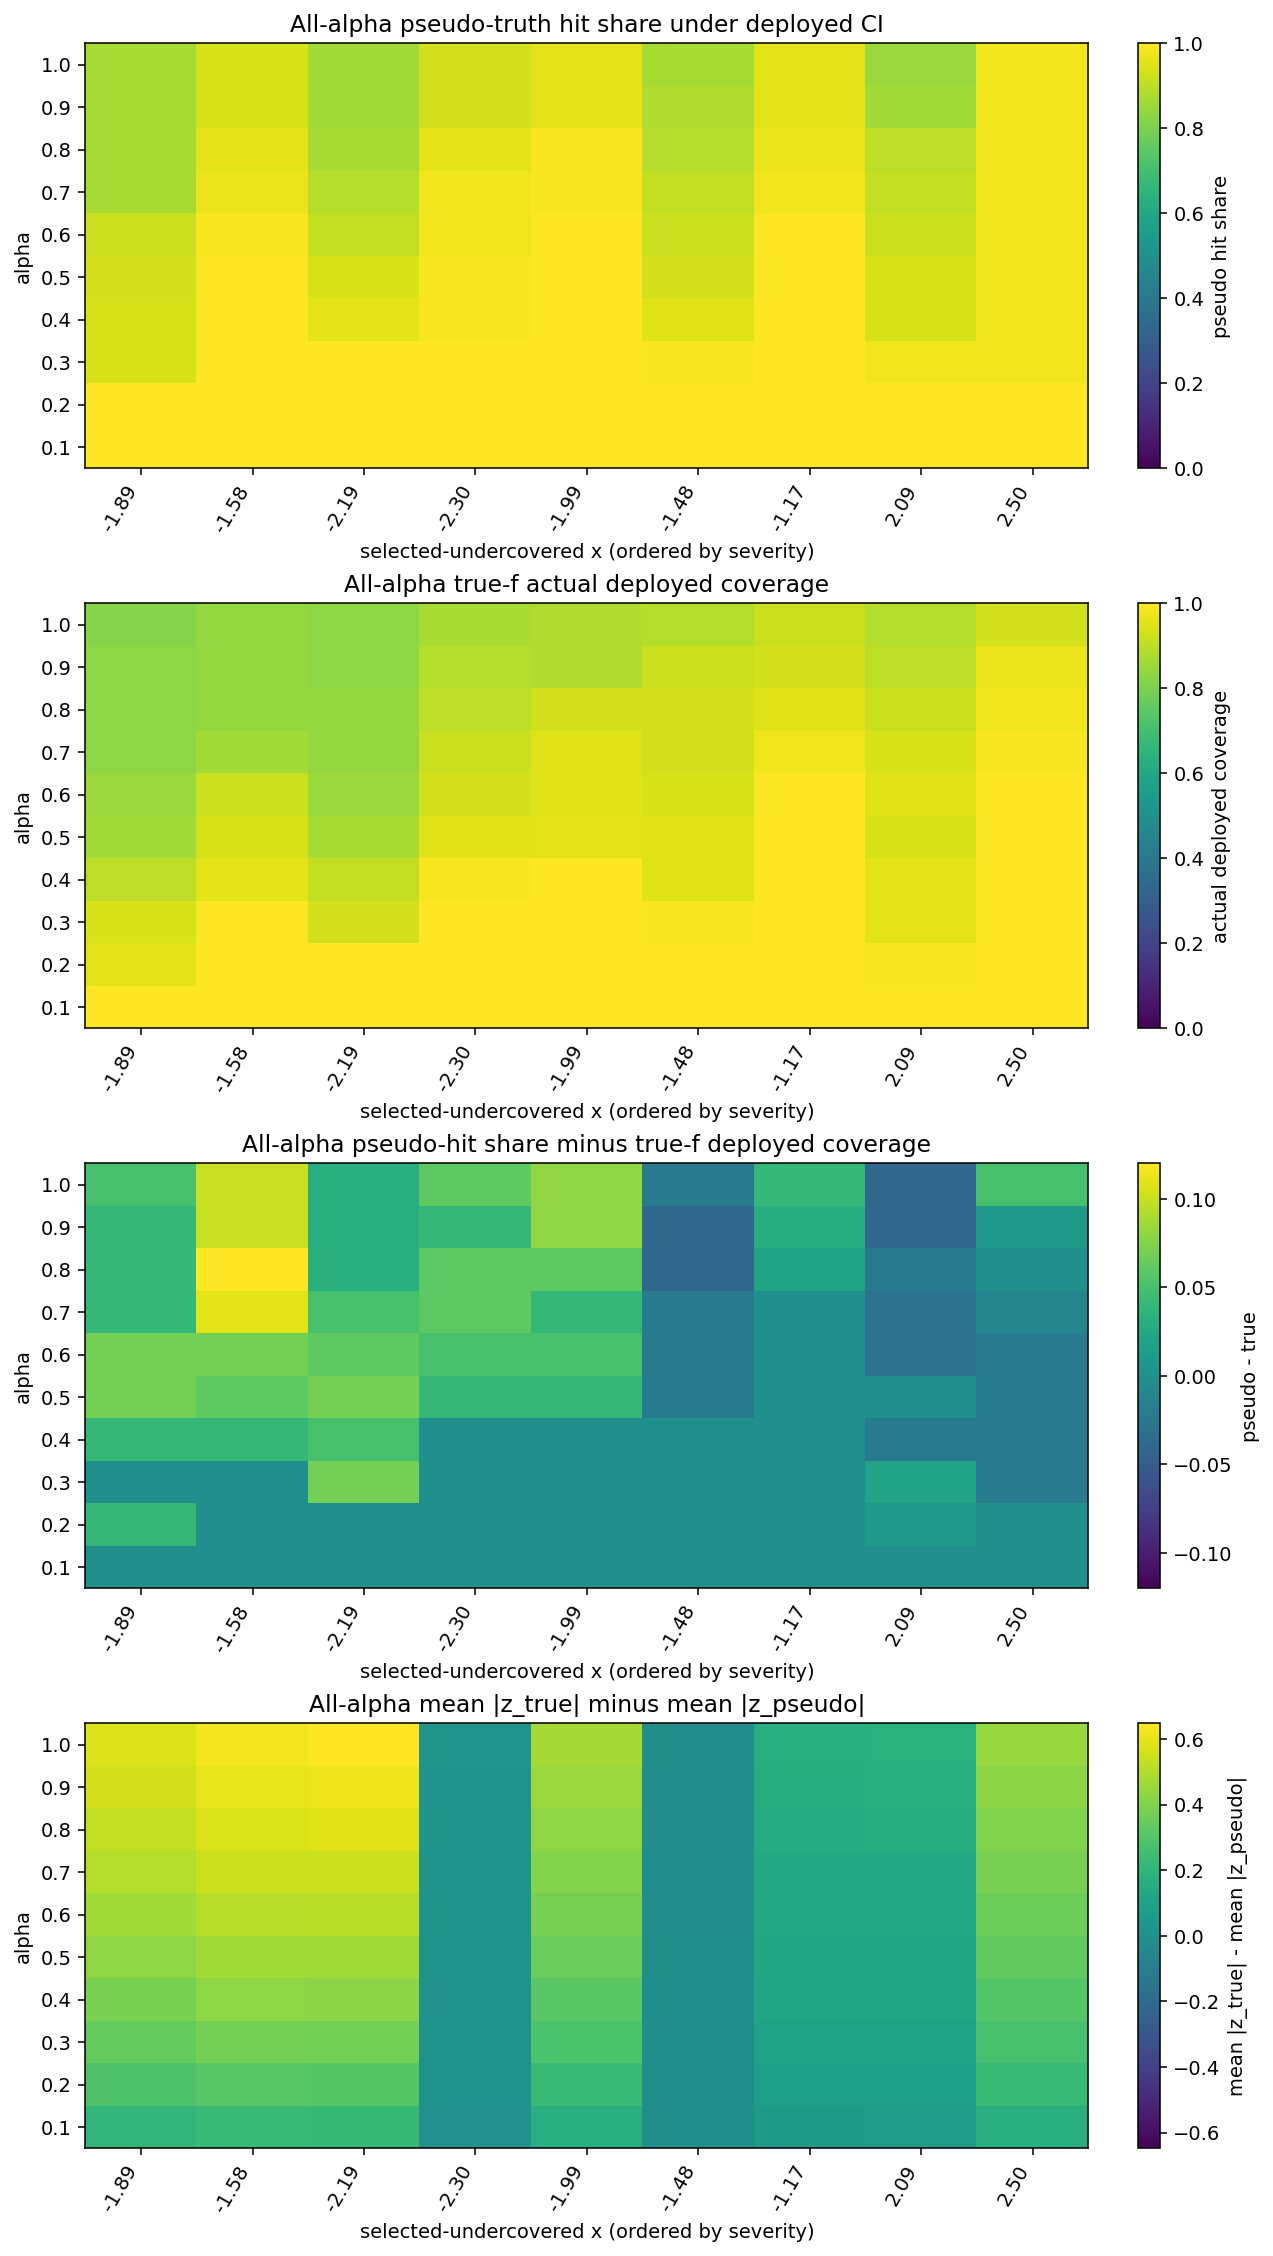

In [12]:

pseudo_hit_all_tensor = (
    (pseudo_all_tensor >= lower_all_tensor) &
    (pseudo_all_tensor <= upper_all_tensor)
).astype(float)

pseudo_z_all_tensor = (pseudo_all_tensor - mu_all_tensor) / np.maximum(std_all_tensor, eps)
true_z_all_tensor = (true_f_ref[None, :, None] - mu_all_tensor) / np.maximum(std_all_tensor, eps)

pseudo_hit_all_mean = pseudo_hit_all_tensor.mean(axis=0)
mean_abs_pseudo_z_all = np.abs(pseudo_z_all_tensor).mean(axis=0)
mean_abs_true_z_all = np.abs(true_z_all_tensor).mean(axis=0)

if U > 0:
    severity_order = np.argsort(pointwise_selected_actual[under_idx])
    under_idx_ord = under_idx[severity_order]
    under_x_ord = x_ref[under_idx_ord]

    pseudo_hit_under = pseudo_hit_all_mean[under_idx_ord, :]
    actual_hit_under = actual_cov_all_mean[under_idx_ord, :]
    hit_gap_under = pseudo_hit_under - actual_hit_under

    abs_pseudo_z_under = mean_abs_pseudo_z_all[under_idx_ord, :]
    abs_true_z_under = mean_abs_true_z_all[under_idx_ord, :]
    abs_z_gap_under = abs_true_z_under - abs_pseudo_z_under

    fig, axes = plt.subplots(4, 1, figsize=(max(9, 0.55 * U), 16), constrained_layout=True)

    im0 = axes[0].imshow(pseudo_hit_under.T, aspect="auto", origin="lower", vmin=0.0, vmax=1.0)
    axes[0].set_title("All-alpha pseudo-truth hit share under deployed CI")
    axes[0].set_xlabel("selected-undercovered x (ordered by severity)")
    axes[0].set_ylabel("alpha")
    axes[0].set_xticks(np.arange(U))
    axes[0].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[0].set_yticks(np.arange(A))
    axes[0].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im0, ax=axes[0], label="pseudo hit share")

    im1 = axes[1].imshow(actual_hit_under.T, aspect="auto", origin="lower", vmin=0.0, vmax=1.0)
    axes[1].set_title("All-alpha true-f actual deployed coverage")
    axes[1].set_xlabel("selected-undercovered x (ordered by severity)")
    axes[1].set_ylabel("alpha")
    axes[1].set_xticks(np.arange(U))
    axes[1].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[1].set_yticks(np.arange(A))
    axes[1].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im1, ax=axes[1], label="actual deployed coverage")

    vmax_hit_gap = np.max(np.abs(hit_gap_under)) if hit_gap_under.size else 1.0
    im2 = axes[2].imshow(hit_gap_under.T, aspect="auto", origin="lower", vmin=-vmax_hit_gap, vmax=vmax_hit_gap)
    axes[2].set_title("All-alpha pseudo-hit share minus true-f deployed coverage")
    axes[2].set_xlabel("selected-undercovered x (ordered by severity)")
    axes[2].set_ylabel("alpha")
    axes[2].set_xticks(np.arange(U))
    axes[2].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[2].set_yticks(np.arange(A))
    axes[2].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im2, ax=axes[2], label="pseudo - true")

    vmax_abs_z_gap = np.max(np.abs(abs_z_gap_under)) if abs_z_gap_under.size else 1.0
    im3 = axes[3].imshow(abs_z_gap_under.T, aspect="auto", origin="lower", vmin=-vmax_abs_z_gap, vmax=vmax_abs_z_gap)
    axes[3].set_title("All-alpha mean |z_true| minus mean |z_pseudo|")
    axes[3].set_xlabel("selected-undercovered x (ordered by severity)")
    axes[3].set_ylabel("alpha")
    axes[3].set_xticks(np.arange(U))
    axes[3].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[3].set_yticks(np.arange(A))
    axes[3].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im3, ax=axes[3], label="mean |z_true| - mean |z_pseudo|")

    plt.savefig(OUTPUT_DIR / "08_undercovered_all_alpha_pseudo_vs_true_heatmaps.png", bbox_inches="tight")
    plt.show()


In [13]:

# Long-format helper table for the selected-undercovered points
long_rows = []
if U > 0:
    for j in under_idx:
        for ai, alpha in enumerate(alpha_vals_ref):
            long_rows.append({
                "x": float(x_ref[j]),
                "true_f": float(true_f_ref[j]),
                "alpha": float(alpha),
                "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
                "selected_estimated_coverage": float(pointwise_selected_estimated[j]),
                "actual_deployed_coverage_mean": float(actual_cov_all_mean[j, ai]),
                "estimated_coverage_mean": float(est_cov_all_mean[j, ai]),
                "pseudo_hit_share_under_deployed_CI": float(pseudo_hit_all_mean[j, ai]),
                "pseudo_minus_true_hit_share": float(pseudo_hit_all_mean[j, ai] - actual_cov_all_mean[j, ai]),
                "mean_abs_pseudo_z_under_deployed_CI": float(mean_abs_pseudo_z_all[j, ai]),
                "mean_abs_true_z_under_deployed_CI": float(mean_abs_true_z_all[j, ai]),
                "mean_abs_true_minus_pseudo_z": float(mean_abs_true_z_all[j, ai] - mean_abs_pseudo_z_all[j, ai]),
                "mean_signed_pseudo_z": float(pseudo_z_all_tensor[:, j, ai].mean()),
                "mean_signed_true_z": float(true_z_all_tensor[:, j, ai].mean()),
            })
undercovered_long_df = pd.DataFrame(long_rows)
undercovered_long_df.to_csv(OUTPUT_DIR / "09_undercovered_all_alpha_pseudo_vs_true_long.csv", index=False)
undercovered_long_df.head() if U > 0 else None


,x,true_f,alpha,selected_actual_deploy_coverage,selected_estimated_coverage,actual_deployed_coverage_mean,estimated_coverage_mean,pseudo_hit_share_under_deployed_CI,pseudo_minus_true_hit_share,mean_abs_pseudo_z_under_deployed_CI,mean_abs_true_z_under_deployed_CI,mean_abs_true_minus_pseudo_z,mean_signed_pseudo_z,mean_signed_true_z
0,-2.295918,-0.547295,0.1,0.88,0.9707,1.00,1.0000,1.00,0.00,0.259206,0.268115,0.008909,-0.041110,-0.268115
1,-2.295918,-0.547295,0.2,0.88,0.9707,1.00,0.9967,1.00,0.00,0.352995,0.365030,0.012035,-0.055852,-0.365030
2,-2.295918,-0.547295,0.3,0.88,0.9707,1.00,0.9910,1.00,0.00,0.423629,0.438228,0.014598,-0.067324,-0.438228
3,-2.295918,-0.547295,0.4,0.88,0.9707,0.99,0.9816,0.99,0.00,0.482336,0.499015,0.016678,-0.076907,-0.499015
4,-2.295918,-0.547295,0.5,0.88,0.9707,0.95,0.9715,0.99,0.04,0.534558,0.552405,0.017848,-0.084709,-0.552405


In [14]:

print("==== CHAIN AUDIT SUMMARY ====")
for k, v in summary.items():
    print(f"{k}: {v}")

print()
print("Key saved outputs:")
print(f" {OUTPUT_DIR / '00_chain_audit_summary.csv'}")
print(f" {OUTPUT_DIR / '00_reconstruction_consistency_per_rep.csv'}")
print(f" {OUTPUT_DIR / '01_object_chain_table.csv'}")
print(f" {OUTPUT_DIR / '03_undercovered_selected_chain_summary.csv'}")
print(f" {OUTPUT_DIR / '04_undercovered_best_alpha_chain_compare.csv'}")
print(f" {OUTPUT_DIR / '06_undercovered_selected_center_offset_summary.csv'}")
print(f" {OUTPUT_DIR / '09_undercovered_all_alpha_pseudo_vs_true_long.csv'}")


==== CHAIN AUDIT SUMMARY ====
R: 100
J: 50
A: 10
rep_id_min: 0
rep_id_max: 99
nominal: 0.95
undercovered_selected_points: 9
recon_all_alpha_curve_match: True
recon_all_mu_match: True
recon_all_std_match: True
recon_all_lower_match: True
recon_all_upper_match: True
recon_all_hit_match: True

Key saved outputs:
 C:\Users\yangy\26 spring\with reference\familyfix\results\chain_audit\00_chain_audit_summary.csv
 C:\Users\yangy\26 spring\with reference\familyfix\results\chain_audit\00_reconstruction_consistency_per_rep.csv
 C:\Users\yangy\26 spring\with reference\familyfix\results\chain_audit\01_object_chain_table.csv
 C:\Users\yangy\26 spring\with reference\familyfix\results\chain_audit\03_undercovered_selected_chain_summary.csv
 C:\Users\yangy\26 spring\with reference\familyfix\results\chain_audit\04_undercovered_best_alpha_chain_compare.csv
 C:\Users\yangy\26 spring\with reference\familyfix\results\chain_audit\06_undercovered_selected_center_offset_summary.csv
 C:\Users\yangy\26 spring\wit